<a href="https://colab.research.google.com/github/maheva82-blip/MarianaHernandez_DS_reto_AprendizajeSupervisado/blob/main/Solucion_Reto_SC_63_Mariana_Hernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reto | Mercadotecnia Telefónica con Aprendizaje Supervisado
Mariana Hernández Vázquez

1.	Deberás utilizar el archivo llamado bank_marketing.csv. con los datos de problema.
2.	Utilizar el archivo bank-names.txt para obtener información de cada una de las variables.
3.	Crear un proyecto tipo Jupyter Notebook en Google-Colab llamado Solucion_Reto_SC_63_<nombre_y_apellido_del_estudiante>.ipynb.
4.	Incluye las librerías que consideres adecuadas y carga los datos del archivo en una variable llamada “data”.

In [113]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
reto_file = files.upload()
file_name = "bank_marketing.csv"

Saving bank_marketing.csv to bank_marketing.csv


In [84]:
data = pd.read_csv(file_name, encoding="latin-1")
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,42,blue-collar,married,secondary,no,314,yes,yes,unknown,16,may,269,2,-1,0,unknown,no
8996,32,blue-collar,married,secondary,no,491,yes,no,unknown,8,may,223,2,-1,0,unknown,no
8997,44,services,single,secondary,no,2886,no,no,unknown,20,jun,31,1,-1,0,unknown,no
8998,57,services,married,primary,no,491,yes,no,cellular,15,apr,1217,3,-1,0,unknown,yes


5.	Obtener la información de dicha base de datos que incluya el número de registros, el total de variables, el tipo de cada variable, la cantidad de datos perdidos de cada variable en caso de que existan.

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


In [86]:
data.nunique()

,0
age,74
job,12
marital,3
education,4
default,2
balance,3476
housing,2
loan,2
contact,3
day,31


In [87]:
for i in data.columns:
  if data[i].dtype == "object":
    print(i, data[i].value_counts())

job job
management       1999
blue-collar      1688
technician       1485
admin.           1004
services          771
retired           594
self-employed     319
student           312
unemployed        290
housemaid         246
entrepreneur      241
unknown            51
Name: count, dtype: int64
marital marital
married     5124
single      2837
divorced    1039
Name: count, dtype: int64
education education
secondary    4486
tertiary     2893
primary      1244
unknown       377
Name: count, dtype: int64
default default
no     8865
yes     135
Name: count, dtype: int64
housing housing
no     4564
yes    4436
Name: count, dtype: int64
loan loan
no     7820
yes    1180
Name: count, dtype: int64
contact contact
cellular     6438
unknown      1982
telephone     580
Name: count, dtype: int64
month month
may    2361
jul    1287
aug    1227
jun    1023
nov     723
apr     707
feb     557
oct     293
jan     289
sep     234
mar     208
dec      91
Name: count, dtype: int64
poutcome poutcome
unk

6.	Transforma las variables categóricas de manera que puedan ser tratadas numéricamente. Justifica si utilizas LabelEncoder o OneHotEcoder.

In [88]:
data = data.replace(['?', 'Unknown', 'N/A', 'nan', 'NaN', 'unknown'], np.nan)

for i in data.columns:
  if data[i].dtype == "object":
    moda = data[i].mode()[0]
    data[i] = data[i].fillna(moda)

data.nunique()

,0
age,74
job,11
marital,3
education,3
default,2
balance,3476
housing,2
loan,2
contact,2
day,31


In [89]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,secondary,no,1584,no,no,cellular,6,sep,245,1,-1,0,failure,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,failure,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,failure,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes


In [90]:
# Por la cantidad de entradas por variable se determina utilizar el LabelEncoder,
# las variables donde es yes o no, igual el label encoder puede transformarlas de manera adecuada
le = LabelEncoder()
columnas = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

for i in columnas:
  data[i] = data[i].astype(str)
  data[i] = le.fit_transform(data[i])

In [91]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,6,1,2,0,2666,0,0,0,10,9,318,2,97,6,2,1
1,29,10,2,1,0,1584,0,0,0,6,11,245,1,-1,0,0,1
2,41,1,1,1,0,2152,1,0,0,17,9,369,1,-1,0,0,0
3,50,1,1,1,0,84,1,0,0,17,5,18,8,-1,0,0,0
4,40,0,1,1,0,0,0,0,0,28,5,496,2,182,11,2,1


7.	Transforma las variables numéricas en los casos que se tenga algún tipo de sesgo.

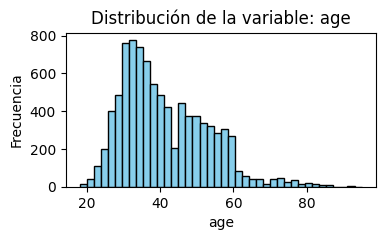

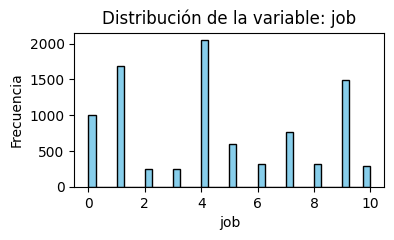

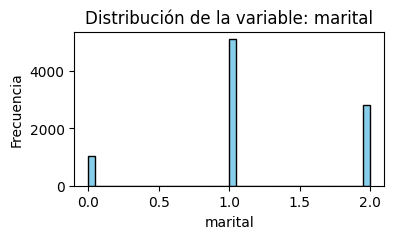

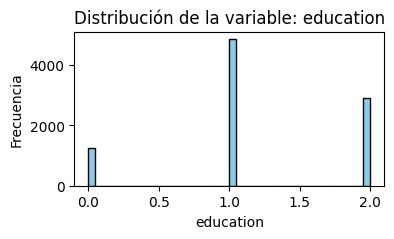

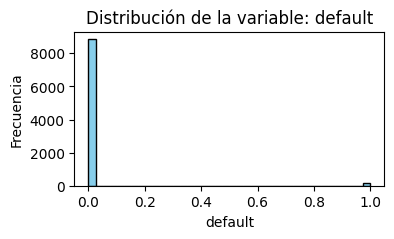

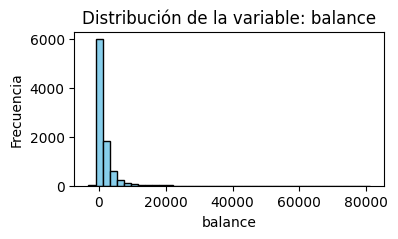

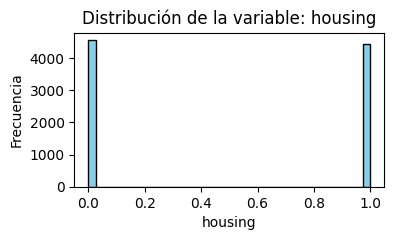

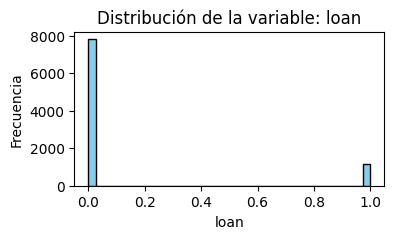

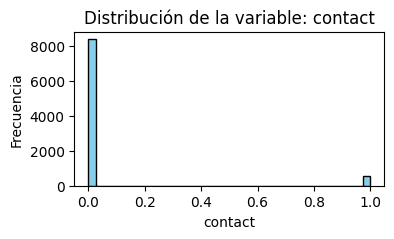

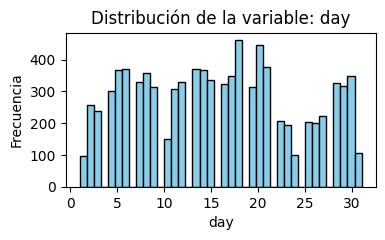

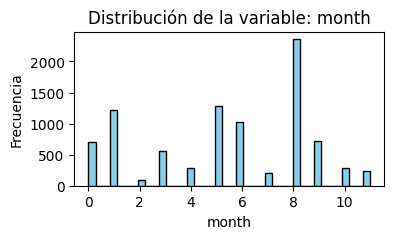

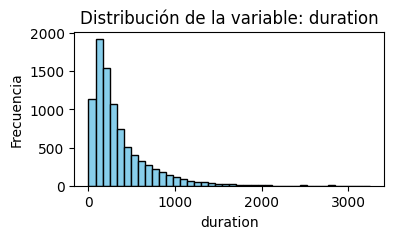

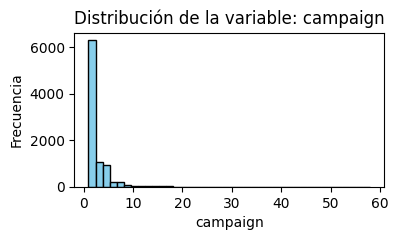

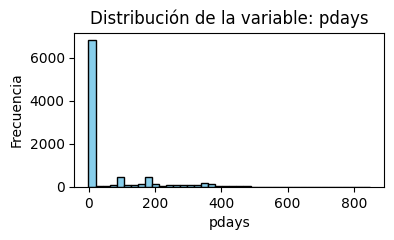

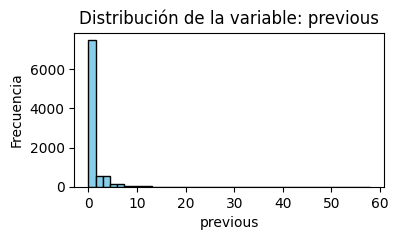

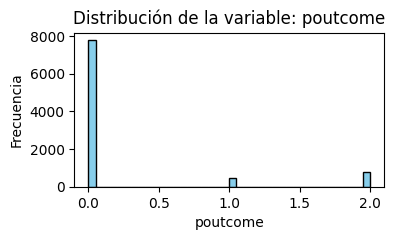

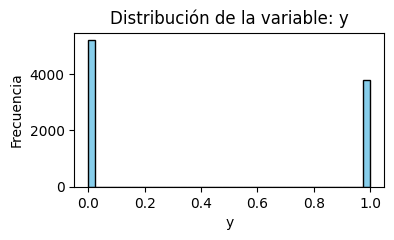

In [92]:
for columna in data.columns:
  plt.figure(figsize=(4, 2))
  plt.hist(data[columna], bins=40, color='skyblue', edgecolor='black')
  plt.title(f"Distribución de la variable: {columna}")
  plt.xlabel(columna)
  plt.ylabel("Frecuencia")
  plt.show()


In [93]:
def norm_esc(X):
	return (X - np.mean(X)) / np.std(X)

In [94]:
def elim_sesgo_pos(X):
  return np.log(X+1)

In [95]:
columnas_sesgo = ['age','duration', 'campaign', 'previous']
for i in columnas_sesgo:
  data[i] = elim_sesgo_pos(data[i])
columnas_escala = [ 'balance', 'day',  'pdays']
for i in columnas_escala:
  data[i] = norm_esc(data[i])

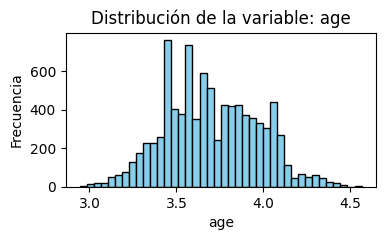

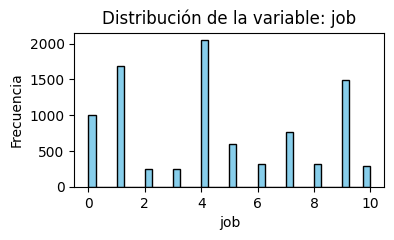

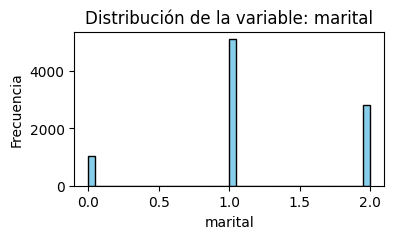

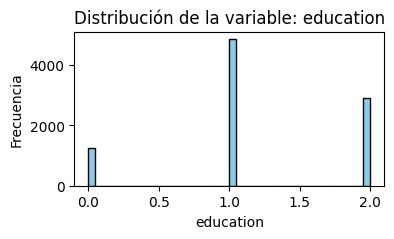

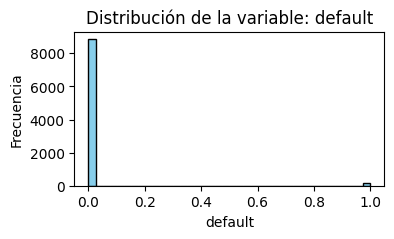

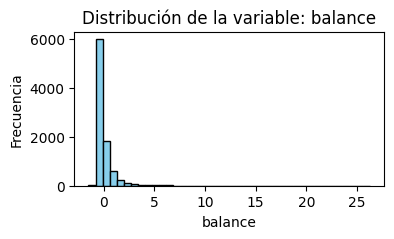

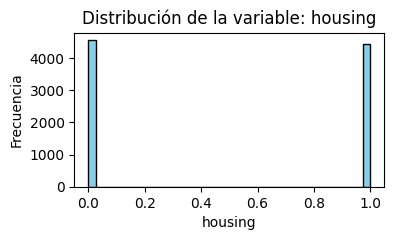

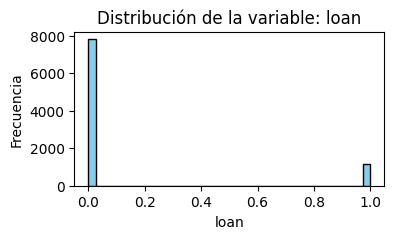

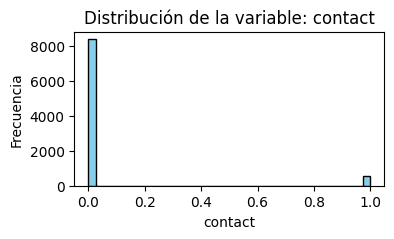

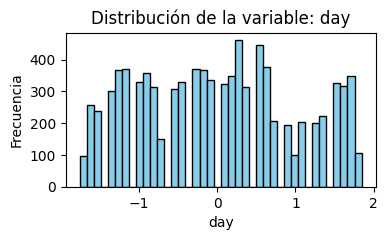

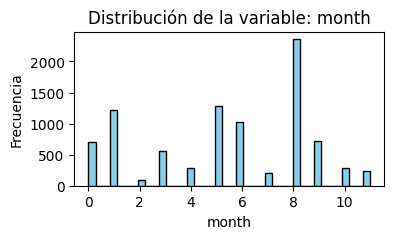

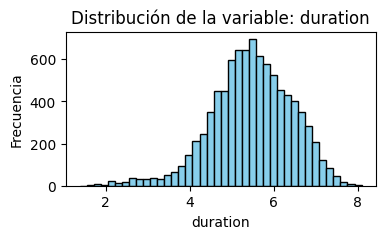

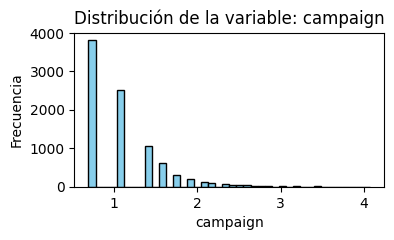

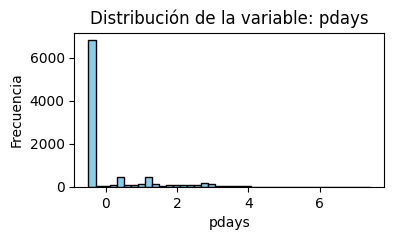

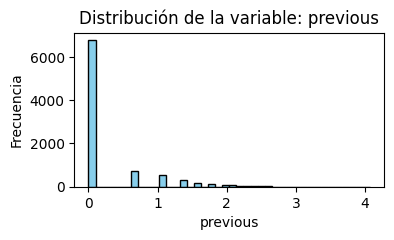

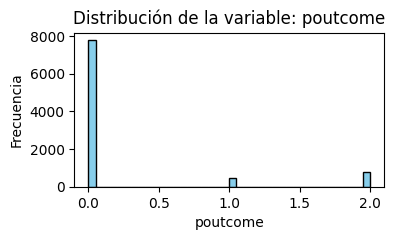

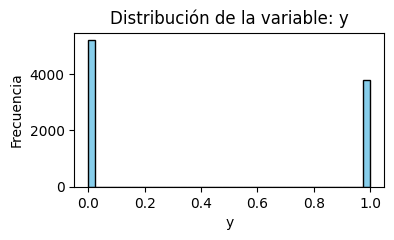

In [96]:
for columna in data.columns:
  plt.figure(figsize=(4, 2))
  plt.hist(data[columna], bins=40, color='skyblue', edgecolor='black')
  plt.title(f"Distribución de la variable: {columna}")
  plt.xlabel(columna)
  plt.ylabel("Frecuencia")
  plt.show()

8.	Considera la variable “y” como la variable de salida y el resto de las variables como las variables de entrada.


In [97]:
X = data[['age', 'job', 'marital','education','default','balance', 'housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome']]

Y = data['y']
X = X.values
Y = Y.values

9.	Particiona los datos en los conjuntos de entrenamiento, validación y prueba en 60%, 20% y 20%, respectivamente.



In [98]:
x_train, x_validation_and_test, y_train, y_validation_and_test = train_test_split(X, Y, train_size=.60)
x_validation, x_test, y_validation, y_test = train_test_split(x_validation_and_test,y_validation_and_test, test_size=.50)

10.	Aplica el modelo Regresión Logística en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor resultado.

In [100]:
parameters = {'C':[0.1, 0.15, 0.18, 0.2, 0.22, 0.24, 0.28, 0.3],
              'penalty':('l2','elasticnet', 'none'),
              'solver':('newton-cg','saga','lbfgs','sag')}

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
320 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solv

GridSearchCV(estimator=LogisticRegression(max_iter=10000),
             param_grid={'C': [0.1, 0.15, 0.18, 0.2, 0.22, 0.24, 0.28, 0.3],
                         'penalty': ('l2', 'elasticnet', 'none'),
                         'solver': ('newton-cg', 'saga', 'lbfgs', 'sag')})
Los mejores valores encontrados son {'C': 0.3, 'penalty': 'l2', 'solver': 'saga'} con un score de 0.80
0.7944444444444444


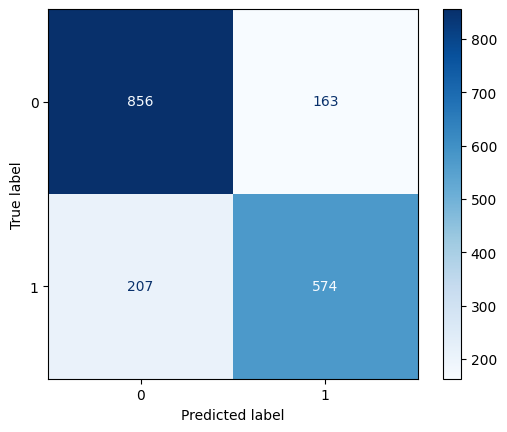

In [114]:
RL_grid = LogisticRegression(max_iter=10000)
modelo_RL_grid = GridSearchCV(RL_grid, parameters)

modelo_RL_grid.fit(x_train, np.ravel(y_train))

print(modelo_RL_grid)

print("Los mejores valores encontrados son %s con un score de %0.2f"
      % (modelo_RL_grid.best_params_, modelo_RL_grid.best_score_))

print(modelo_RL_grid.score(x_validation, y_validation))

ConfusionMatrixDisplay.from_estimator(modelo_RL_grid, x_validation, y_validation, cmap='Blues')

plt.show()

11.	Aplica el modelo Red Neuronal en el conjunto de entrenamiento. Valida el modelo con las predicciones del conjunto de validación y su matriz de confusión. Ajusta los parámetros del modelo hasta obtener tu mejor modelo, entre ellos el número de neuronas y capas ocultas.

In [110]:
neuronas = [i for i in range(1, 50, 3)]

print(neuronas)

[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46, 49]


> 1...	 trainacc: 0.584, valacc: 0.566, trainloss: 0.416, valloss: 0.434
> 4...	 trainacc: 0.799, valacc: 0.788, trainloss: 0.201, valloss: 0.212
> 7...	 trainacc: 0.808, valacc: 0.805, trainloss: 0.192, valloss: 0.195
> 10...	 trainacc: 0.806, valacc: 0.808, trainloss: 0.194, valloss: 0.192
> 13...	 trainacc: 0.805, valacc: 0.802, trainloss: 0.195, valloss: 0.198
> 16...	 trainacc: 0.816, valacc: 0.804, trainloss: 0.184, valloss: 0.196
> 19...	 trainacc: 0.820, valacc: 0.817, trainloss: 0.180, valloss: 0.183
> 22...	 trainacc: 0.814, valacc: 0.803, trainloss: 0.186, valloss: 0.197
> 25...	 trainacc: 0.817, valacc: 0.810, trainloss: 0.183, valloss: 0.190
> 28...	 trainacc: 0.812, valacc: 0.803, trainloss: 0.188, valloss: 0.197
> 31...	 trainacc: 0.822, valacc: 0.813, trainloss: 0.178, valloss: 0.187
> 34...	 trainacc: 0.818, valacc: 0.809, trainloss: 0.182, valloss: 0.191
> 37...	 trainacc: 0.821, valacc: 0.811, trainloss: 0.179, valloss: 0.189
> 40...	 trainacc: 0.825, valacc: 0.811, 

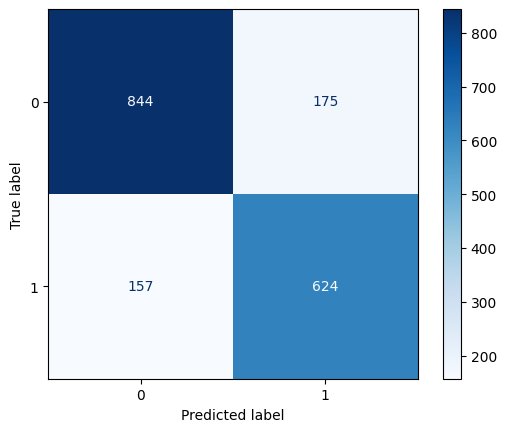

In [121]:
train_scores, val_scores = list(), list()

train_errors, val_errors = list(), list()
for i in neuronas:

  model = MLPClassifier(hidden_layer_sizes=(i,i),
                        max_iter=1000,
                        alpha=0.73,
                        random_state=43)

  model.fit(x_train, y_train)

  # Predicciones y métricas con el conjunto de entrenamiento:
  train_yhat = model.predict(x_train)

  train_loss =  np.mean(abs(y_train - train_yhat))
  train_errors.append(train_loss)

  train_acc = 1 - train_loss
  train_scores.append(train_acc)

  # Predicciones y métricas con el conjunto de validación:
  val_yhat = model.predict(x_validation)

  val_loss = np.mean(abs(y_validation - val_yhat))
  val_errors.append(val_loss)

  val_acc = 1 - val_loss
  val_scores.append(val_acc)

  # evolución de las métricas durante el entrenamiento ...
  print('> %d...\t trainacc: %.3f, valacc: %.3f, trainloss: %.3f, valloss: %.3f'
        % (i, train_acc, val_acc, train_loss, val_loss))

ConfusionMatrixDisplay.from_estimator(model, x_validation, y_validation, cmap='Blues')

plt.show()

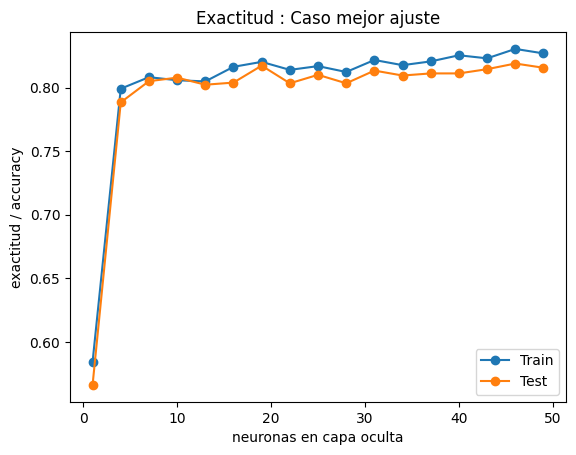

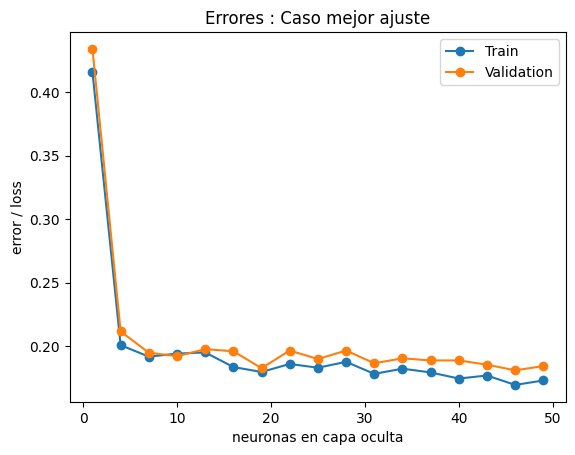

In [122]:
plt.plot(neuronas, train_scores, '-o', label='Train')
plt.plot(neuronas, val_scores, '-o', label='Test')
plt.legend()
plt.title('Exactitud : Caso mejor ajuste')
plt.xlabel('neuronas en capa oculta')
plt.ylabel('exactitud / accuracy')
plt.show()


plt.plot(neuronas, train_errors, '-o', label='Train')
plt.plot(neuronas,val_errors, '-o', label='Validation')
plt.legend()
plt.title('Errores : Caso mejor ajuste')
plt.xlabel('neuronas en capa oculta')
plt.ylabel('error / loss')
plt.show()

12.	Selecciona el mejor modelo encontrado en los incisos anteriores y utiliza el conjunto de prueba para obtener el desempeño final del modelo y su matriz de confusión.

0.8138888888888889


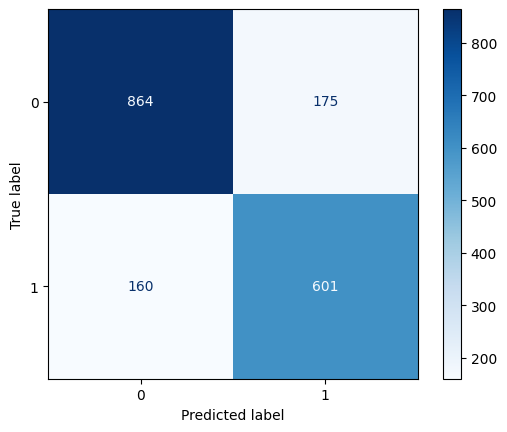

In [125]:
modelo_RL_tmp = LogisticRegression( C=0.3,
                                   penalty='l2',
                                   solver='saga',
                                   max_iter=10000)

modelo_RL_tmp.fit( x_train, np.ravel(y_train) )

print(modelo_RL_tmp.score(x_test, y_test))

ConfusionMatrixDisplay.from_estimator(modelo_RL_tmp, x_test, y_test, cmap='Blues')

plt.show()

> 49...	 trainacc: 0.808, testacc: 0.826, trainloss: 0.192, testloss: 0.174


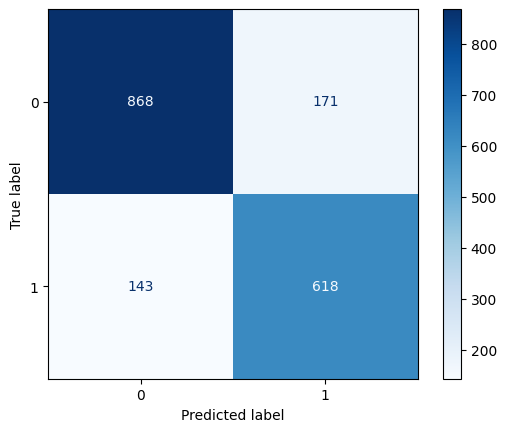

In [124]:
model = MLPClassifier(hidden_layer_sizes=(7,7),
                        max_iter=1000,
                        alpha=0.73,
                        random_state=43)

model.fit(x_train, y_train)

# Predicciones y métricas con el conjunto de entrenamiento:
train_yhat = model.predict(x_train)

train_loss =  np.mean(abs(y_train - train_yhat))
train_errors.append(train_loss)

train_acc = 1 - train_loss
train_scores.append(train_acc)

# Predicciones y métricas con el conjunto de validación:
test_yhat = model.predict(x_test)

test_loss = np.mean(abs(y_test - test_yhat))

test_acc = 1 - test_loss

# evolución de las métricas durante el entrenamiento ...
print('> %d...\t trainacc: %.3f, testacc: %.3f, trainloss: %.3f, testloss: %.3f'
        % (i, train_acc, test_acc, train_loss, test_loss))

ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap='Blues')

plt.show()


13.	Incluye tus conclusiones del problema, en particular, ¿qué puedes decir acerca del uso de técnicas de inteligencia artificial en problemas de mercadotecnia?

Es posible hacer uso de un modelo de Regresión Lineal y/o un modelo de redes neuronales teniendo una efectividad de alrededor del 80% - 82%

14.	Descarga tu script (archivo con extensión .ipynb) y guárdalo siguiendo la nomenclatura que se te indica en Formato de entrega de actividad.  
15.	Sube el archivo a GitHub.  
16.	Copia y pega en un archivo de edición de texto la liga de tu archivo.